# 🛒 Online Retail II Sales Analysis

## 📌 Project Overview

This project analyzes transactional data from an online retail company using **Python**, **SQL**, and **Power BI**.

The objective is to transform raw sales data into meaningful business insights by performing:

- Data Cleaning
- Data Validation
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Business Insights
- Data Visualization

The cleaned dataset will later be used for SQL analysis and Power BI dashboard development.

---

## 🎯 Business Objectives

This project aims to answer the following business questions:

- How much revenue did the company generate?
- Which products generate the highest sales?
- Who are the most valuable customers?
- Which countries contribute the most revenue?
- How do sales change over time?
- When are customers most active?

---

## 🛠 Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Power BI

---

## 📂 Dataset

**Dataset:** Online Retail II

The dataset contains transactional records of an online gift retailer between **December 2009 and December 2011**.

Each row represents a purchased product within an invoice.

---

In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

print("Libraries imported successfully.")

Libraries imported successfully.


# 📥 Load Dataset

The dataset is loaded into a pandas DataFrame.

This allows us to inspect, clean, transform, and analyze the transactional data.

In [3]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("online_retail_II.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# 🔍 Initial Data Inspection

Before performing any cleaning or analysis, it is important to understand the structure and contents of the dataset.

The following checks will be performed:

- Dataset dimensions
- Preview of records
- Column names
- Data types
- Summary statistics

In [4]:
# ==========================================================
# DATASET DIMENSIONS
# ==========================================================

print("Rows and Columns:")

df.shape

Rows and Columns:


(1067371, 8)

In [5]:
# ==========================================================
# FIRST FIVE ROWS
# ==========================================================

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
# ==========================================================
# LAST FIVE ROWS
# ==========================================================

df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [7]:
# ==========================================================
# COLUMN NAMES
# ==========================================================

df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'], dtype='str')

In [8]:
# ============================================================
# Dataset Information
# ============================================================

# Display column names, data types,
# and missing values.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [9]:
# ==========================================================
# SUMMARY STATISTICS
# ==========================================================

df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


# 🔄 Data Type Validation

Before cleaning the dataset, we verify that each column has the correct data type.

Correct data types are essential because they enable accurate calculations, filtering, grouping, and time-based analysis.

For this dataset:

- **InvoiceDate** should be stored as a datetime object.
- **Customer ID** will later be converted to an integer after removing missing values.
- All remaining columns already have appropriate data types.

In [10]:
# ============================================================
# Display Current Data Types
# ============================================================

df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [11]:
# ============================================================
# Convert InvoiceDate to Datetime
# ============================================================

# InvoiceDate is currently stored as a string.
# Converting it to datetime enables:
# • Yearly analysis
# • Monthly analysis
# • Daily analysis
# • Hourly analysis

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [12]:
# ============================================================
# Verify Data Types
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 65.1 MB


## Observation

The data types were successfully validated.

- InvoiceDate has been converted to datetime format.
- All other columns already use appropriate data types.
- Customer ID will be converted to an integer after handling missing values.

The dataset is now ready for a detailed data quality assessment.

# 🧹 Data Quality Assessment

Before performing any analysis, the dataset must be assessed for data quality issues.

Poor-quality data can lead to incorrect insights and misleading business decisions.

The following checks will be performed:

1. Missing Values
2. Duplicate Records
3. Missing Product Descriptions
4. Missing Customer IDs
5. Cancelled Transactions
6. Invalid Quantities
7. Invalid Prices

Based on these findings, appropriate cleaning steps will be applied.

## 1. Missing Values

Missing values can affect calculations, visualizations, and business insights.

We first identify the number of missing values in each column.

In [13]:
# ============================================================
# Check Missing Values
# ============================================================

# Count missing values in each column.

missing_values = df.isnull().sum()

missing_values

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [14]:
# ============================================================
# Calculate Missing Value Percentage
# ============================================================

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(ascending=False)

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

### Observation

The missing value analysis shows:

- **Customer ID** contains a large number of missing values.
- **Description** contains a small number of missing values.
- All remaining columns have no missing values.

These missing records will be investigated before deciding whether they should be removed.

## 2. Duplicate Records

Duplicate rows can inflate revenue, sales quantity, and customer metrics.

The dataset is checked for exact duplicate transactions.

In [15]:
# ============================================================
# Check Duplicate Records
# ============================================================

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows:,}")

Duplicate Rows : 34,335


### Observation

The dataset contains duplicate rows.

Since duplicate transactions would result in double-counting sales and revenue, they should be removed before analysis.

In [16]:
# ============================================================
# Remove Duplicate Records
# ============================================================

df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


## 3. Missing Product Descriptions

Product descriptions are important for product-level analysis.

Rows with missing descriptions are investigated before removal to determine whether they represent valid sales transactions.

In [17]:
# ============================================================
# Investigate Missing Product Descriptions
# ============================================================

df[df["Description"].isnull()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom


In [18]:
# Number of missing descriptions

df["Description"].isnull().sum()

np.int64(4275)

### Evidence

The investigation showed that these records generally contain:

- Missing product descriptions
- Missing customer IDs
- Unit Price equal to 0
- Inventory adjustment or non-sale transactions

Since these records do not represent valid customer purchases and cannot contribute to product or revenue analysis, they will be removed.

In [19]:
# ============================================================
# Remove Missing Product Descriptions
# ============================================================

df = df.dropna(subset=["Description"])

print("Rows with missing descriptions removed.")

Rows with missing descriptions removed.


## 4. Missing Customer IDs

Customer IDs are required for customer-level analysis.

Without a customer identifier, it is impossible to determine:

- Number of customers
- Repeat customers
- Customer Lifetime Value
- Customer purchasing behavior

These records are investigated before removal.

In [20]:
# ============================================================
# Check Missing Customer IDs
# ============================================================

df["Customer ID"].isnull().sum()

np.int64(230876)

### Evidence

The project includes customer analysis.

Transactions without Customer IDs cannot be linked to individual customers and therefore cannot be used for customer-level insights.

These records will be removed.

In [21]:
# ============================================================
# Remove Missing Customer IDs
# ============================================================

df = df.dropna(subset=["Customer ID"])

print("Rows with missing Customer IDs removed.")

Rows with missing Customer IDs removed.


## 5. Cancelled Transactions

Invoices beginning with the letter **"C"** represent cancelled orders.

Cancelled transactions should not be included in revenue analysis because they do not represent completed sales.

In [22]:
# ============================================================
# Count Cancelled Invoices
# ============================================================

cancelled_orders = df["Invoice"].str.startswith("C").sum()

print(f"Cancelled Orders : {cancelled_orders:,}")

Cancelled Orders : 18,390


In [23]:
# Display a few cancelled transactions

df[df["Invoice"].str.startswith("C")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


### Evidence

Cancelled invoices represent reversed transactions.

Including them would reduce revenue and distort sales performance.

Therefore, these records will be removed.

In [24]:
# ============================================================
# Remove Cancelled Transactions
# ============================================================

df = df[~df["Invoice"].str.startswith("C")]

print("Cancelled invoices removed.")

Cancelled invoices removed.


## 6. Invalid Quantities

A valid sales transaction must have a positive quantity.

Negative quantities usually represent returned products or cancelled purchases.

In [25]:
# ============================================================
# Check Invalid Quantities
# ============================================================

(df["Quantity"] <= 0).sum()

np.int64(0)

In [26]:
# Remove invalid quantities

df = df[df["Quantity"] > 0]

### Evidence

Transactions with zero or negative quantities do not represent completed product purchases.

Removing these records ensures that only valid sales are included in the analysis.

In [27]:
# ============================================================
# Check Invalid Prices
# ============================================================

(df["Price"] <= 0).sum()

np.int64(70)

In [28]:
# Remove invalid prices

df = df[df["Price"] > 0]

### Evidence

Products with zero or negative prices do not contribute to revenue.

Removing these records ensures accurate financial analysis.

In [29]:
# ============================================================
# Reset Index
# ============================================================

df = df.reset_index(drop=True)

In [30]:
# ============================================================
# Convert Customer ID to Integer
# ============================================================

# Missing Customer IDs have been removed.
# Convert to integer for better readability.

df["Customer ID"] = df["Customer ID"].astype(int)

In [31]:
# ============================================================
# Verify Cleaned Dataset
# ============================================================

print("Shape:", df.shape)

print("\nMissing Values")
display(df.isnull().sum())

print("\nDataset Information")
df.info()

print("\nSummary Statistics")
display(df.describe())

Shape: (779425, 8)

Missing Values


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 47.6 MB

Summary Statistics


,Quantity,InvoiceDate,Price,Customer ID
count,779425.000000,779425,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,145.855814,NaN,29.676140,1695.692775


# Data Cleaning Summary

The following data cleaning steps were completed:

- Removed duplicate records to prevent double-counting.
- Removed rows with missing product descriptions.
- Removed rows with missing Customer IDs.
- Removed cancelled invoices identified by invoice numbers starting with "C".
- Removed transactions with non-positive quantities.
- Removed transactions with non-positive prices.
- Converted Customer ID to integer after handling missing values.
- Reset the DataFrame index.

The dataset now contains only valid completed sales transactions and is ready for feature engineering and exploratory data analysis.

# ⚙️ Feature Engineering

Feature engineering is the process of creating new variables from existing data.

These new features simplify analysis and help answer business questions related to:

- Revenue
- Sales trends
- Customer purchasing behavior
- Seasonality
- Peak shopping hours

The following features will be created:

- Revenue
- Year
- Month
- Month Name
- Quarter
- Day
- Weekday
- Hour

## 1. Create Revenue Column

### Business Reason

The dataset contains **Quantity** and **Unit Price**, but it does not contain the total revenue generated by each transaction.

Revenue is one of the most important business metrics and is calculated as:

> **Revenue = Quantity × Unit Price**

In [32]:
# ============================================================
# Create Revenue Column
# ============================================================

# Revenue represents the total sales value
# generated from each transaction.

df["Revenue"] = df["Quantity"] * df["Price"]

# Preview the new column
df[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


## 2. Extract Year

### Business Reason

Extracting the year enables yearly sales analysis and helps identify long-term business trends.

In [33]:
# ============================================================
# Extract Year
# ============================================================

df["Year"] = df["InvoiceDate"].dt.year

df[["InvoiceDate", "Year"]].head()

,InvoiceDate,Year
0,2009-12-01 07:45:00,2009
1,2009-12-01 07:45:00,2009
2,2009-12-01 07:45:00,2009
3,2009-12-01 07:45:00,2009
4,2009-12-01 07:45:00,2009


## 3. Extract Month Number

### Business Reason

Month numbers are useful for sorting and calculating monthly sales trends.

In [34]:
# ============================================================
# Extract Month Number
# ============================================================

df["Month"] = df["InvoiceDate"].dt.month

df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2009-12-01 07:45:00,12
1,2009-12-01 07:45:00,12
2,2009-12-01 07:45:00,12
3,2009-12-01 07:45:00,12
4,2009-12-01 07:45:00,12


## 4. Extract Month Name

### Business Reason

Month names improve the readability of reports and visualizations.

In [35]:
# ============================================================
# Extract Month Name
# ============================================================

df["Month_Name"] = df["InvoiceDate"].dt.month_name()

df[["InvoiceDate", "Month_Name"]].head()

,InvoiceDate,Month_Name
0,2009-12-01 07:45:00,December
1,2009-12-01 07:45:00,December
2,2009-12-01 07:45:00,December
3,2009-12-01 07:45:00,December
4,2009-12-01 07:45:00,December


## 5. Extract Quarter

### Business Reason

Businesses often review performance on a quarterly basis.

Creating a Quarter column makes quarterly analysis straightforward.

In [36]:
# ============================================================
# Extract Quarter
# ============================================================

df["Quarter"] = df["InvoiceDate"].dt.quarter

df[["InvoiceDate", "Quarter"]].head()

,InvoiceDate,Quarter
0,2009-12-01 07:45:00,4
1,2009-12-01 07:45:00,4
2,2009-12-01 07:45:00,4
3,2009-12-01 07:45:00,4
4,2009-12-01 07:45:00,4


## 6. Extract Day

### Business Reason

Extracting the day of the month allows us to analyze daily purchasing patterns.

In [37]:
# ============================================================
# Extract Day
# ============================================================

df["Day"] = df["InvoiceDate"].dt.day

df[["InvoiceDate", "Day"]].head()

,InvoiceDate,Day
0,2009-12-01 07:45:00,1
1,2009-12-01 07:45:00,1
2,2009-12-01 07:45:00,1
3,2009-12-01 07:45:00,1
4,2009-12-01 07:45:00,1


## 7. Extract Weekday

### Business Reason

Weekday analysis helps determine which days generate the highest sales and customer activity.

In [38]:
# ============================================================
# Extract Weekday
# ============================================================

df["Weekday"] = df["InvoiceDate"].dt.day_name()

df[["InvoiceDate", "Weekday"]].head()

,InvoiceDate,Weekday
0,2009-12-01 07:45:00,Tuesday
1,2009-12-01 07:45:00,Tuesday
2,2009-12-01 07:45:00,Tuesday
3,2009-12-01 07:45:00,Tuesday
4,2009-12-01 07:45:00,Tuesday


## 8. Extract Hour

### Business Reason

The hour of each transaction helps identify peak shopping hours, which can support staffing and marketing decisions.

In [39]:
# ============================================================
# Extract Hour
# ============================================================

df["Hour"] = df["InvoiceDate"].dt.hour

df[["InvoiceDate", "Hour"]].head()

,InvoiceDate,Hour
0,2009-12-01 07:45:00,7
1,2009-12-01 07:45:00,7
2,2009-12-01 07:45:00,7
3,2009-12-01 07:45:00,7
4,2009-12-01 07:45:00,7


# Verify Engineered Features

The newly created features are reviewed to ensure they have been generated correctly.

In [40]:
# ============================================================
# Preview Dataset with New Features
# ============================================================

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Quarter,Day,Weekday,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,December,4,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,4,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,4,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,December,4,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,December,4,1,Tuesday,7


In [41]:
# ============================================================
# Verify Dataset Information
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  str           
 8   Revenue      779425 non-null  float64       
 9   Year         779425 non-null  int32         
 10  Month        779425 non-null  int32         
 11  Month_Name   779425 non-null  str           
 12  Quarter      779425 non-null  int32         
 13  Day          779425 non-null  int32         
 14  Weekday      779425 non-null  str           
 15  Hour         779425 non-null  int32         


In [85]:
# Rename column to match SQL
df.rename(columns={"Customer ID": "CustomerID"}, inplace=True)

# Verify
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day', 'Weekday', 'Hour'], dtype='str')


## Feature Engineering Summary

The following features were successfully created:

- **Revenue**: Total sales value for each transaction.
- **Year**: Used for yearly trend analysis.
- **Month**: Used for chronological sorting and monthly analysis.
- **Month_Name**: Improves chart readability.
- **Quarter**: Supports quarterly performance analysis.
- **Day**: Enables daily sales analysis.
- **Weekday**: Helps identify the busiest days of the week.
- **Hour**: Used to analyze peak shopping hours.

These engineered features provide the foundation for the exploratory data analysis in the next section.

# 💾 Export Cleaned Dataset

After completing data cleaning and feature engineering, the cleaned dataset is exported.

Saving the cleaned dataset provides several benefits:

- Ensures consistency across Python, SQL, and Power BI.
- Avoids repeating the cleaning process.
- Creates a reusable dataset for future analysis.

The cleaned dataset will be stored in the `data/processed` folder.

In [86]:
# ============================================================
# Export Cleaned Dataset
# ============================================================

# Save the cleaned dataset for future analysis
# This dataset will be used in SQL and Power BI.

df.to_csv(
    "online_retail_cleaned.csv",
    index=False
)

print("✅ Cleaned dataset exported successfully.")

✅ Cleaned dataset exported successfully.


In [43]:
# ============================================================
# Verify Export
# ============================================================

# Display the shape of the final cleaned dataset.

print(f"Final Dataset Shape : {df.shape}")

df.head()

Final Dataset Shape : (779425, 16)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Quarter,Day,Weekday,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,December,4,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,4,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,4,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,December,4,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,December,4,1,Tuesday,7


# 📊 Exploratory Data Analysis (EDA)

With the dataset cleaned and enriched, the next step is to explore the data to uncover meaningful business insights.

The analysis will answer questions such as:

- What is the overall business performance?
- How have sales changed over time?
- Which products generate the most revenue?
- Who are the most valuable customers?
- Which countries contribute the highest sales?
- When are customers most active?

The analysis is organized into the following sections:

1. Business Overview (KPIs)
2. Sales Analysis
3. Product Analysis
4. Customer Analysis
5. Country Analysis
6. Time Analysis

# 📊 1. Business Overview (Key Performance Indicators)

## Objective

Before diving into detailed analysis, it is important to understand the overall performance of the business.

Key Performance Indicators (KPIs) provide a high-level summary of the company's sales, customers, and products.

The following KPIs will be calculated:

- Total Revenue
- Total Orders
- Total Customers
- Total Products Sold
- Unique Products
- Average Order Value
- Average Revenue per Customer

## KPI 1 — Total Revenue

### Business Question

**How much revenue did the company generate from completed sales?**

Revenue is one of the most important business metrics because it measures the total income generated from valid customer transactions.

Since the dataset has already been cleaned by removing cancelled orders, invalid quantities, invalid prices, and duplicate records, the calculated revenue represents completed sales only.

In [44]:
# ============================================================
# KPI 1 : Total Revenue
# ============================================================

# The dataset has already been cleaned by removing:
# • Duplicate transactions
# • Cancelled invoices
# • Missing Customer IDs
# • Missing Descriptions
# • Invalid quantities
# • Invalid prices
#
# Therefore, the revenue calculated below represents
# revenue from valid completed sales only.

total_revenue = df["Revenue"].sum()

print(f"Total Revenue : £{total_revenue:,.2f}")

Total Revenue : £17,374,804.27


### Business Insight

The total revenue represents the total value of all completed sales after data cleaning.

This KPI serves as the primary measure of business performance and will be used as a benchmark throughout the analysis.

## KPI 2 — Total Orders

### Business Question

**How many completed orders were placed by customers?**

Each unique invoice represents a completed customer order.

Tracking the number of orders helps measure customer purchasing activity and overall business demand.

In [45]:
# ============================================================
# KPI 2 : Total Orders
# ============================================================

# Each unique invoice represents one completed order.

total_orders = df["Invoice"].nunique()

print(f"Total Orders : {total_orders:,}")

Total Orders : 36,969


### Business Insight

The total number of completed orders reflects overall customer purchasing activity.

This KPI is useful for understanding demand and is later used to calculate the Average Order Value (AOV).

## KPI 3 — Total Customers

### Business Question

**How many unique customers made purchases?**

This metric measures the size of the active customer base during the analysis period.

In [46]:
# ============================================================
# KPI 3 : Total Customers
# ============================================================

# Count unique customers.

total_customers = df["Customer ID"].nunique()

print(f"Total Customers : {total_customers:,}")

Total Customers : 5,878


### Business Insight

A larger customer base generally indicates broader market reach.

This KPI is also used later to calculate the average revenue generated per customer.

## KPI 4 — Total Products Sold

### Business Question

**How many individual products were sold?**

This KPI measures the total quantity of items purchased by customers.

In [47]:
# ============================================================
# KPI 4 : Total Products Sold
# ============================================================

# Sum of all quantities sold.

total_products_sold = df["Quantity"].sum()

print(f"Products Sold : {total_products_sold:,}")

Products Sold : 10,513,952


### Business Insight

The total quantity sold indicates the overall sales volume and helps assess inventory movement.

## KPI 5 — Unique Products

### Business Question

**How many different products were sold?**

This KPI measures product diversity and indicates the breadth of the company's product catalog.

In [48]:
# ============================================================
# KPI 5 : Unique Products
# ============================================================

# Count unique Stock Codes.

unique_products = df["StockCode"].nunique()

print(f"Unique Products : {unique_products:,}")

Unique Products : 4,631


### Business Insight

A higher number of unique products reflects a broader product offering and greater product variety.

## KPI 6 — Average Order Value (AOV)

### Business Question

**What is the average revenue generated per completed order?**

Average Order Value measures how much customers spend on average each time they place an order.

Formula:

**Average Order Value = Total Revenue ÷ Total Orders**

In [49]:
# ============================================================
# KPI 6 : Average Order Value
# ============================================================

average_order_value = total_revenue / total_orders

print(f"Average Order Value : £{average_order_value:,.2f}")

Average Order Value : £469.98


### Business Insight

A higher Average Order Value indicates that customers are spending more per transaction.

Businesses often use this KPI to evaluate pricing strategies, promotions, and cross-selling opportunities.

## KPI 7 — Average Revenue per Customer

### Business Question

**How much revenue does each customer generate on average?**

This KPI estimates the average revenue contributed by an individual customer.

Formula:

**Average Revenue per Customer = Total Revenue ÷ Total Customers**

In [50]:
# ============================================================
# KPI 7 : Average Revenue per Customer
# ============================================================

average_revenue_per_customer = total_revenue / total_customers

print(f"Average Revenue per Customer : £{average_revenue_per_customer:,.2f}")

Average Revenue per Customer : £2,955.90


### Business Insight

This metric provides a high-level estimate of customer value.

It serves as a useful benchmark before performing more advanced customer analyses, such as identifying top customers or calculating customer lifetime value.

# 📋 KPI Summary Table

To provide a concise overview of business performance, all key performance indicators are summarized in a single table.

In [51]:
# ============================================================
# KPI Summary Table
# ============================================================

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Products Sold",
        "Unique Products",
        "Average Order Value",
        "Average Revenue per Customer"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products_sold:,}",
        f"{unique_products:,}",
        f"£{average_order_value:,.2f}",
        f"£{average_revenue_per_customer:,.2f}"
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,"£17,374,804.27"
1,Total Orders,"36,969"
2,Total Customers,"5,878"
3,Products Sold,"10,513,952"
4,Unique Products,"4,631"
5,Average Order Value,£469.98
6,Average Revenue per Customer,"£2,955.90"


## Business Overview Summary

The KPIs provide a high-level summary of the company's performance after cleaning the dataset.

Key observations include:

- Total revenue generated from valid completed sales.
- Number of completed customer orders.
- Size of the active customer base.
- Total quantity of products sold.
- Number of unique products offered.
- Average spending per order.
- Average revenue generated per customer.

These metrics establish a baseline for the detailed analyses in the following sections.

# 📈 Sales Analysis

## Objective

The purpose of this section is to analyze how sales have changed over time.

By examining revenue and order trends, we can identify:

- Business growth
- Seasonal patterns
- High-performing months
- Low-performing months
- Customer purchasing behavior over time

The following analyses will be performed:

1. Monthly Revenue Trend
2. Monthly Orders Trend
3. Quarterly Revenue
4. Yearly Revenue
5. Month-over-Month Growth
6. Best & Worst Performing Months

## 2.1 Monthly Revenue Trend

### Business Question

**How did monthly revenue change over time?**

Monthly revenue analysis helps identify:

- Sales growth
- Seasonal demand
- Peak sales periods
- Low-performing months

These insights help businesses plan inventory, staffing, and marketing campaigns.

In [52]:
# ============================================================
# Monthly Revenue
# ============================================================

monthly_revenue = (
    df.groupby(["Year", "Month", "Month_Name"])["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue = monthly_revenue.sort_values(
    ["Year", "Month"]
)

monthly_revenue.head()

,Year,Month,Month_Name,Revenue
0,2009,12,December,683504.010
1,2010,1,January,555802.672
2,2010,2,February,504558.956
3,2010,3,March,696978.471
4,2010,4,April,591982.002


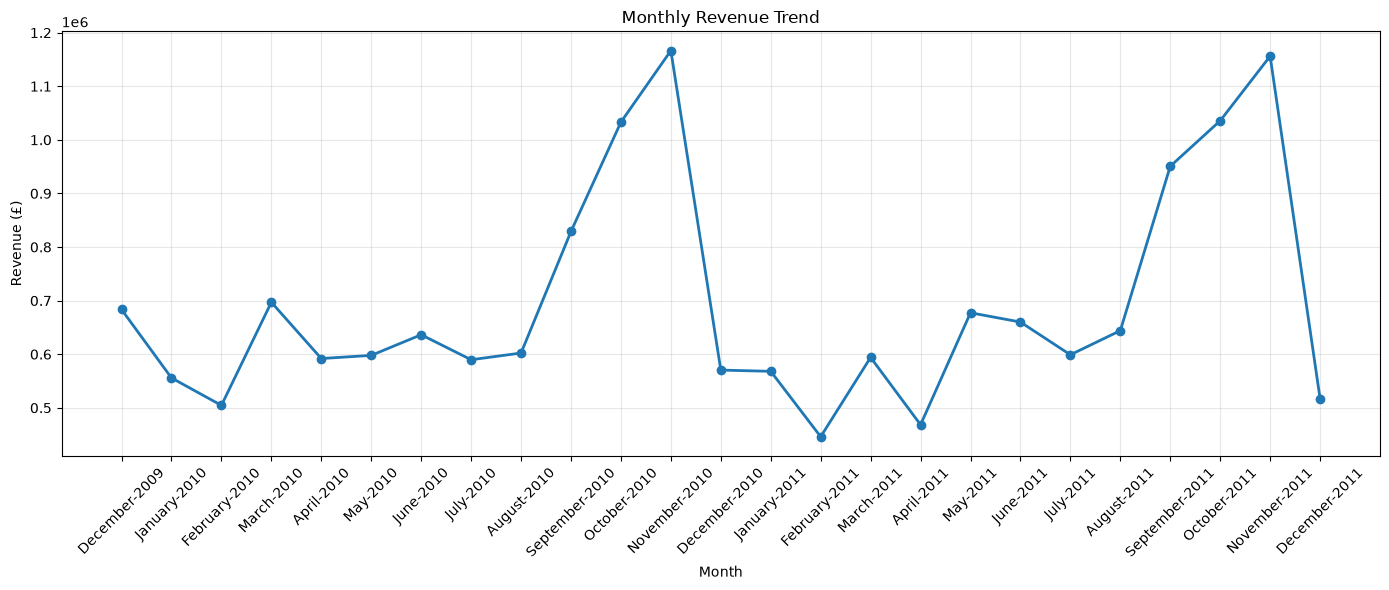

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\monthly_revenue.png


In [53]:
# ============================================================
# Monthly Revenue Trend
# ============================================================
import os
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["Month_Name"] + "-" + monthly_revenue["Year"].astype(str),
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()





script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'monthly_revenue.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")



plt.show()

### Business Insight

The line chart shows how monthly revenue changed throughout the analysis period.

By examining the trend, we can identify periods of strong growth, seasonal demand, and months with lower sales performance.

This information helps management plan future sales strategies.

In [54]:
# ============================================================
# Highest & Lowest Revenue Month
# ============================================================

highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("Highest Revenue Month")
print(highest_month)

print("\nLowest Revenue Month")
print(lowest_month)

Highest Revenue Month
Year                 2010
Month                  11
Month_Name       November
Revenue       1166460.022
Name: 11, dtype: object

Lowest Revenue Month
Year               2011
Month                 2
Month_Name     February
Revenue       446084.92
Name: 14, dtype: object


### Recommendation

Investigate the business activities during the highest-performing month, such as promotions or seasonal demand, and evaluate whether similar strategies can be applied during lower-performing months to improve revenue.

## 2.2 Monthly Orders Trend

### Business Question

**How many customer orders were placed each month?**

Revenue can increase either because customers place more orders or because they spend more per order.

Analyzing order volume helps distinguish between these two factors.

In [55]:
# ============================================================
# Monthly Orders
# ============================================================

monthly_orders = (
    df.groupby(["Year", "Month", "Month_Name"])["Invoice"]
      .nunique()
      .reset_index(name="Orders")
)

monthly_orders = monthly_orders.sort_values(
    ["Year", "Month"]
)

monthly_orders.head()

,Year,Month,Month_Name,Orders
0,2009,12,December,1512
1,2010,1,January,1011
2,2010,2,February,1104
3,2010,3,March,1524
4,2010,4,April,1329


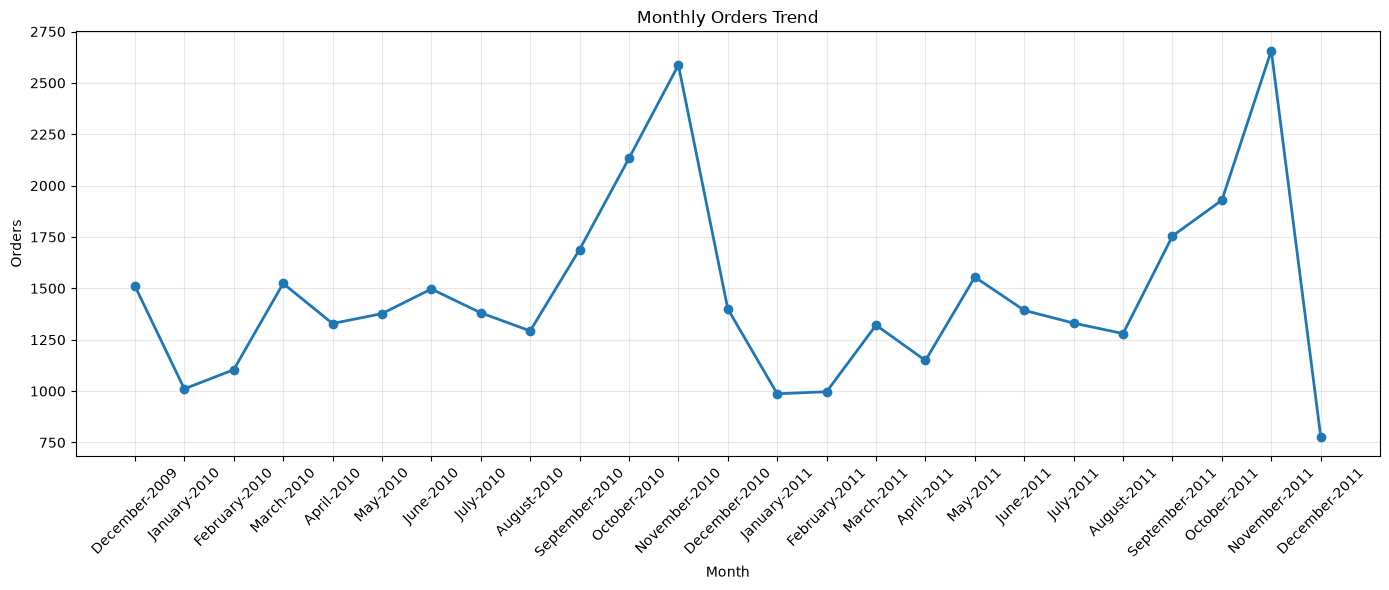

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\monthly_order_trend.png


In [56]:
# ============================================================
# Monthly Orders Trend
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["Month_Name"] + "-" + monthly_orders["Year"].astype(str),
    monthly_orders["Orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Orders Trend")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()




script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'monthly_order_trend.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

Comparing monthly orders with monthly revenue helps determine whether revenue growth is driven by an increase in the number of orders or by higher customer spending.

## 2.3 Quarterly Revenue

### Business Question

**How does revenue vary across business quarters?**

Many organizations evaluate performance on a quarterly basis for financial reporting and strategic planning.

In [57]:
# ============================================================
# Quarterly Revenue
# ============================================================

quarterly_revenue = (
    df.groupby(["Year", "Quarter"])["Revenue"]
      .sum()
      .reset_index()
)

quarterly_revenue

,Year,Quarter,Revenue
0,2009,4,683504.010
1,2010,1,1757340.099
2,2010,2,1826186.512
3,2010,3,2020974.721
4,2010,4,2769994.762
5,2011,1,1608267.990
6,2011,2,1805775.531
7,2011,3,2193704.143
8,2011,4,2709056.500


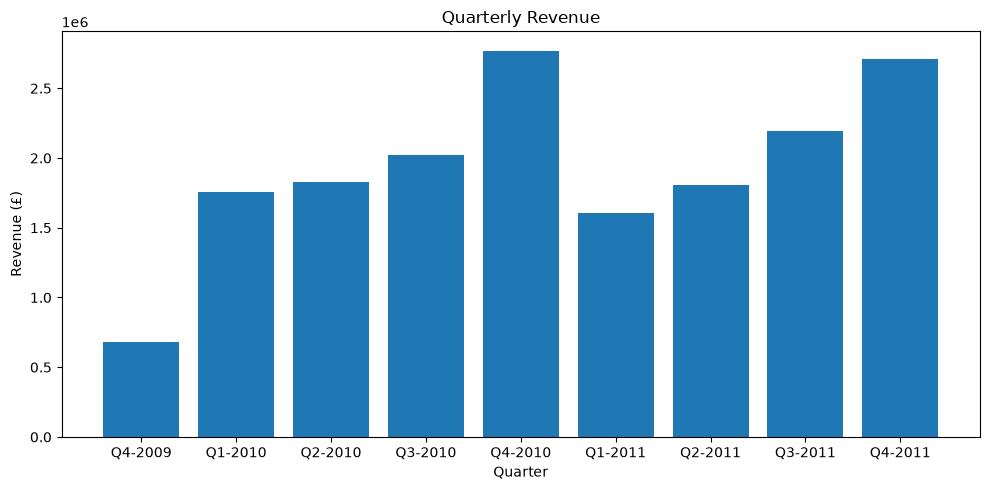

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\Quarterly_revenue.png


In [58]:
# ============================================================
# Quarterly Revenue Chart
# ============================================================

quarter_labels = (
    "Q" + quarterly_revenue["Quarter"].astype(str)
    + "-" +
    quarterly_revenue["Year"].astype(str)
)

plt.figure(figsize=(10,5))

plt.bar(
    quarter_labels,
    quarterly_revenue["Revenue"]
)

plt.title("Quarterly Revenue")

plt.xlabel("Quarter")

plt.ylabel("Revenue (£)")

plt.tight_layout()

import os


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'Quarterly_revenue.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

Quarterly analysis provides a broader view of sales performance and can help identify sustained growth or seasonal trends that may not be obvious in monthly data.

## 2.4 Yearly Revenue

### Business Question

**How has the company's revenue changed each year?**

Yearly revenue analysis highlights long-term business performance and overall growth trends.

In [59]:
# ============================================================
# Yearly Revenue
# ============================================================

yearly_revenue = (
    df.groupby("Year")["Revenue"]
      .sum()
      .reset_index()
)

yearly_revenue

,Year,Revenue
0,2009,683504.010
1,2010,8374496.094
2,2011,8316804.164


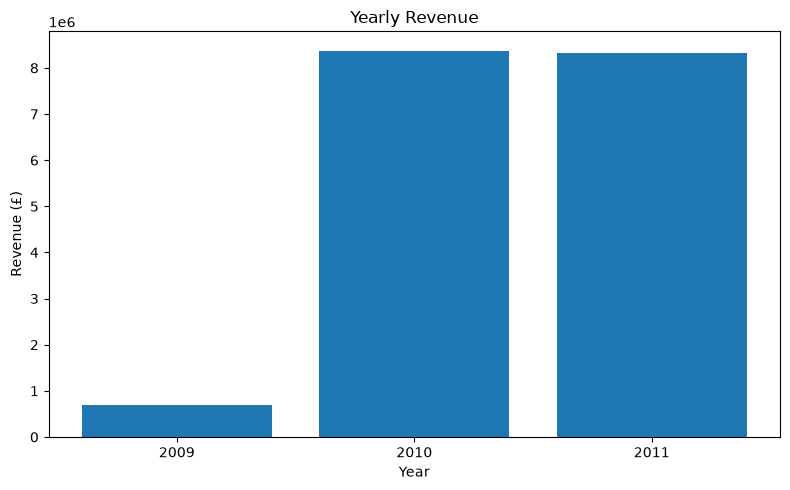

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\yearly_revenue.png


In [60]:
# ============================================================
# Yearly Revenue Chart
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    yearly_revenue["Year"].astype(str),
    yearly_revenue["Revenue"]
)

plt.title("Yearly Revenue")

plt.xlabel("Year")

plt.ylabel("Revenue (£)")

plt.tight_layout()




script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'yearly_revenue.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

Yearly revenue provides a high-level overview of business performance over time.

It helps identify whether the business is experiencing growth, stability, or decline.

## 2.5 Month-over-Month (MoM) Revenue Growth

### Business Question

**How has revenue changed from one month to the next?**

Month-over-Month (MoM) growth measures the percentage increase or decrease in revenue compared to the previous month.

This helps identify periods of rapid growth, decline, or stable performance.

In [61]:
# ============================================================
# Month-over-Month Revenue Growth
# ============================================================

monthly_revenue["Previous_Month_Revenue"] = monthly_revenue["Revenue"].shift(1)

monthly_revenue["MoM_Growth (%)"] = (
    (monthly_revenue["Revenue"] - monthly_revenue["Previous_Month_Revenue"])
    / monthly_revenue["Previous_Month_Revenue"]
) * 100

monthly_revenue.head()

,Year,Month,Month_Name,Revenue,Previous_Month_Revenue,MoM_Growth (%)
0,2009,12,December,683504.010,NaN,NaN
1,2010,1,January,555802.672,683504.010,-18.683334
2,2010,2,February,504558.956,555802.672,-9.219768
3,2010,3,March,696978.471,504558.956,38.136181
4,2010,4,April,591982.002,696978.471,-15.064521


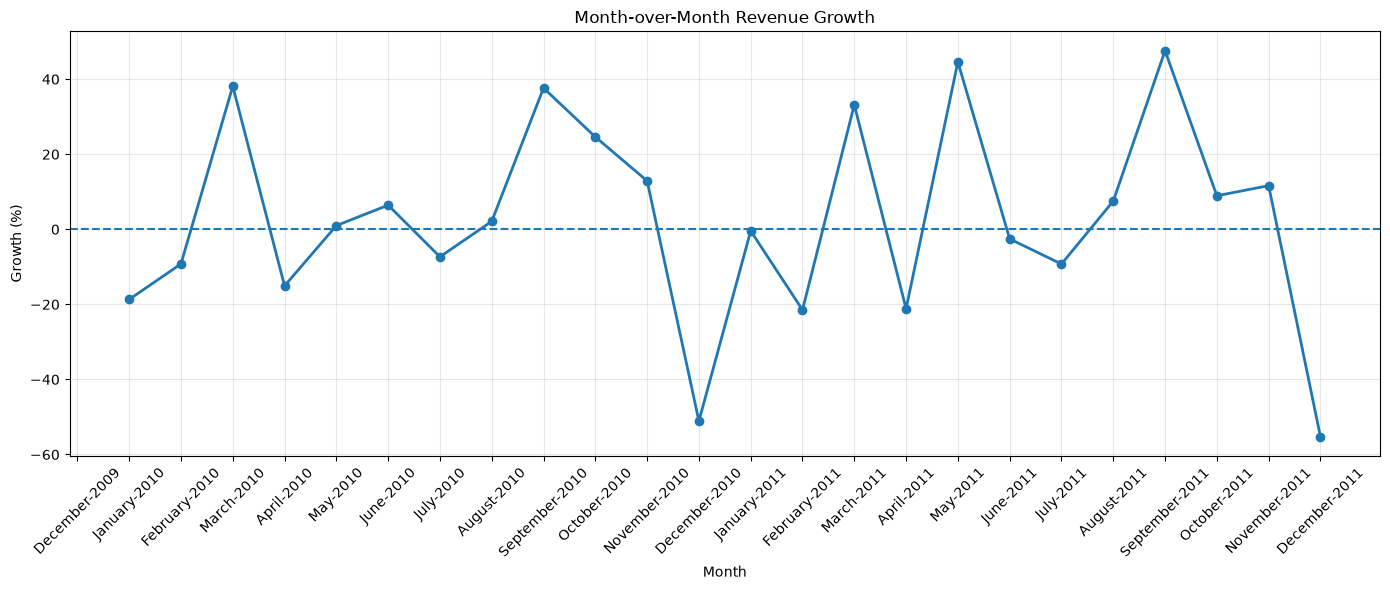

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\monthly_0ver_month_revenue.png


In [62]:
# ============================================================
# Month-over-Month Growth Chart
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["Month_Name"] + "-" + monthly_revenue["Year"].astype(str),
    monthly_revenue["MoM_Growth (%)"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--")

plt.title("Month-over-Month Revenue Growth")

plt.xlabel("Month")

plt.ylabel("Growth (%)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()



script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'monthly_0ver_month_revenue.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

Positive growth percentages indicate an increase in revenue compared to the previous month, while negative values indicate a decline.

Monitoring MoM growth helps businesses quickly identify changing sales patterns and evaluate the impact of promotions, seasonality, or market conditions.

## 2.6 Best & Worst Performing Months

### Business Question

**Which months generated the highest and lowest revenue?**

Identifying the strongest and weakest months helps businesses understand seasonality and improve planning for inventory, staffing, and marketing.

In [63]:
# ============================================================
# Best & Worst Performing Months
# ============================================================

highest_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmax()]

lowest_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmin()]

print("Highest Revenue Month")
display(highest_month.to_frame().T)

print("\nLowest Revenue Month")
display(lowest_month.to_frame().T)

Highest Revenue Month


,Year,Month,Month_Name,Revenue,Previous_Month_Revenue,MoM_Growth (%)
11,2010,11,November,1166460.022,1033112.01,12.907411



Lowest Revenue Month


,Year,Month,Month_Name,Revenue,Previous_Month_Revenue,MoM_Growth (%)
14,2011,2,February,446084.92,568101.31,-21.477928


In [64]:
# ============================================================
# Compare Best & Worst Months
# ============================================================

comparison = pd.DataFrame({
    "Performance": ["Highest Revenue", "Lowest Revenue"],
    "Year": [highest_month["Year"], lowest_month["Year"]],
    "Month": [highest_month["Month_Name"], lowest_month["Month_Name"]],
    "Revenue (£)": [highest_month["Revenue"], lowest_month["Revenue"]]
})

comparison

,Performance,Year,Month,Revenue (£)
0,Highest Revenue,2010,November,1166460.022
1,Lowest Revenue,2011,February,446084.920


### Business Insight

The comparison highlights the months with the strongest and weakest sales performance.

Understanding the reasons behind these differences—such as seasonal demand, holidays, promotions, or operational challenges—can help improve future business planning.

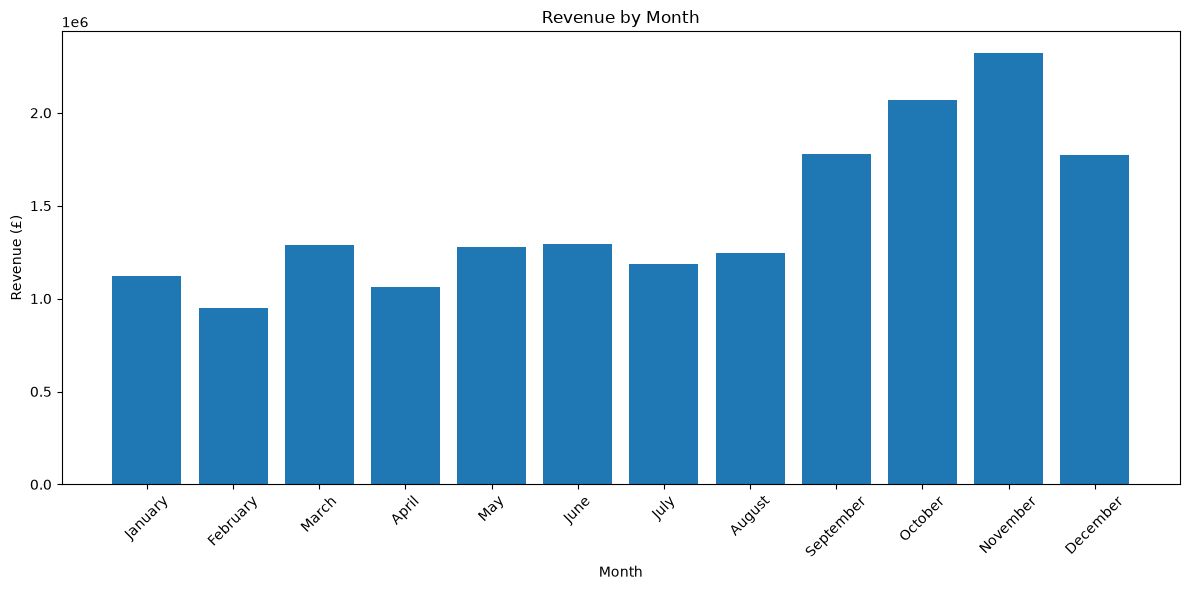

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\revenue_by_month.png


In [65]:
# ============================================================
# Revenue Distribution by Month
# ============================================================

monthly_summary = (
    df.groupby("Month_Name")["Revenue"]
      .sum()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)

plt.figure(figsize=(12,6))

plt.bar(
    monthly_summary.index,
    monthly_summary.values
)

plt.xticks(rotation=45)

plt.title("Revenue by Month")

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.tight_layout()

import os


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'revenue_by_month.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

This visualization aggregates revenue across all years by calendar month, making it easier to identify recurring seasonal patterns.

Months that consistently generate higher revenue may correspond to holidays, promotional events, or increased customer demand.

## Sales Analysis Summary

The sales analysis provided valuable insights into business performance over time.

Key findings include:

- Monthly revenue trends reveal periods of growth and decline.
- Monthly order volume helps explain changes in revenue.
- Quarterly and yearly analysis provides a broader performance overview.
- Month-over-Month growth highlights short-term changes in sales.
- Identifying the best and worst performing months supports better forecasting and planning.

These findings establish a strong understanding of overall sales performance and prepare us for a deeper analysis of product performance.

# 📦 Product Analysis

## Objective

This section evaluates product performance to identify which products contribute the most to business revenue and sales volume.

Understanding product performance helps businesses:

- Identify best-selling products
- Optimize inventory management
- Improve product assortment
- Increase profitability
- Make informed marketing decisions

The following analyses will be performed:

1. Top 10 Products by Revenue
2. Top 10 Products by Quantity Sold
3. Lowest Performing Products
4. Product Revenue Distribution

## 3.1 Top 10 Products by Revenue

### Business Question

**Which products generated the highest revenue?**

Revenue is one of the most important measures of product performance because it reflects both customer demand and product value.

In [66]:
# ============================================================
# Top 10 Products by Revenue
# ============================================================

top_products_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products_revenue

,Description,Revenue
0,REGENCY CAKESTAND 3 TIER,277656.25
1,WHITE HANGING HEART T-LIGHT HOLDER,247048.01
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,Manual,151777.67
4,JUMBO BAG RED RETROSPOT,134307.44
5,POSTAGE,124648.04
6,ASSORTED COLOUR BIRD ORNAMENT,124351.86
7,PARTY BUNTING,103283.38
8,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
9,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18


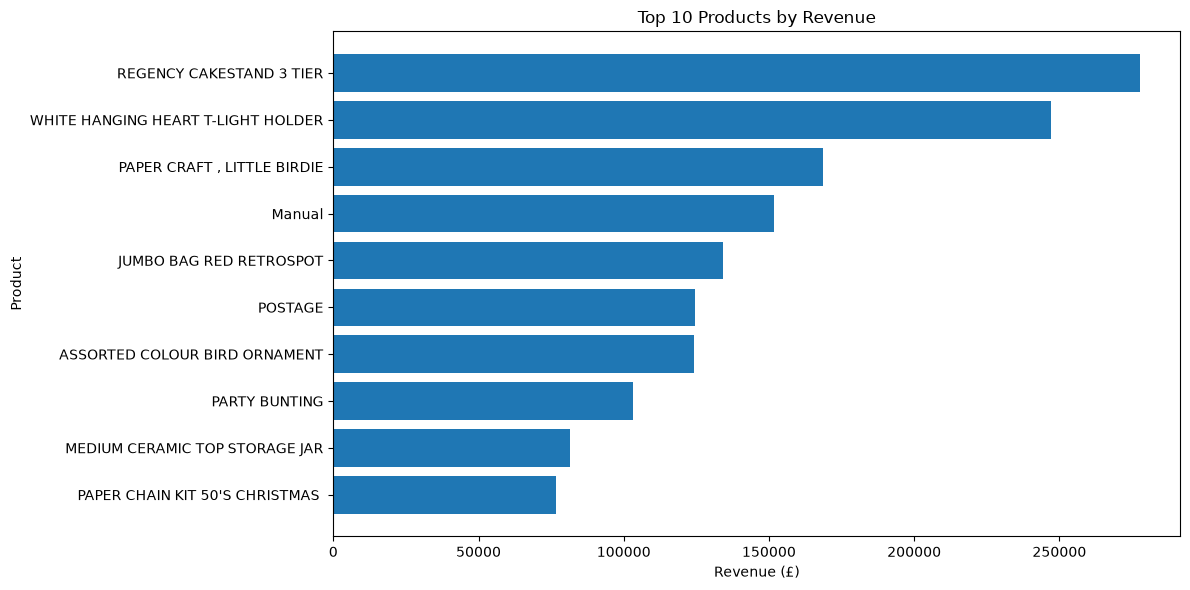

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\Top_products.png


In [67]:
# ============================================================
# Visualization - Top 10 Products by Revenue
# ============================================================

plt.figure(figsize=(12,6))

plt.barh(
    top_products_revenue["Description"],
    top_products_revenue["Revenue"]
)

plt.title("Top 10 Products by Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()

import os


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'Top_products.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

The chart highlights the products that contribute the most revenue.

These products are high-value assets and should be prioritized for:

- Inventory availability
- Marketing campaigns
- Product promotions
- Customer retention strategies

## 3.2 Top 10 Products by Quantity Sold

### Business Question

**Which products sold the highest number of units?**

While revenue measures monetary performance, quantity sold reflects customer demand and product popularity.

In [68]:
# ============================================================
# Top Products by Quantity Sold
# ============================================================

top_products_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products_quantity

,Description,Quantity
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185
1,WHITE HANGING HEART T-LIGHT HOLDER,91757
2,"PAPER CRAFT , LITTLE BIRDIE",80995
3,ASSORTED COLOUR BIRD ORNAMENT,78234
4,MEDIUM CERAMIC TOP STORAGE JAR,77916
5,JUMBO BAG RED RETROSPOT,74224
6,BROCADE RING PURSE,70082
7,PACK OF 60 PINK PAISLEY CAKE CASES,54592
8,60 TEATIME FAIRY CAKE CASES,52828
9,PACK OF 72 RETRO SPOT CAKE CASES,45129


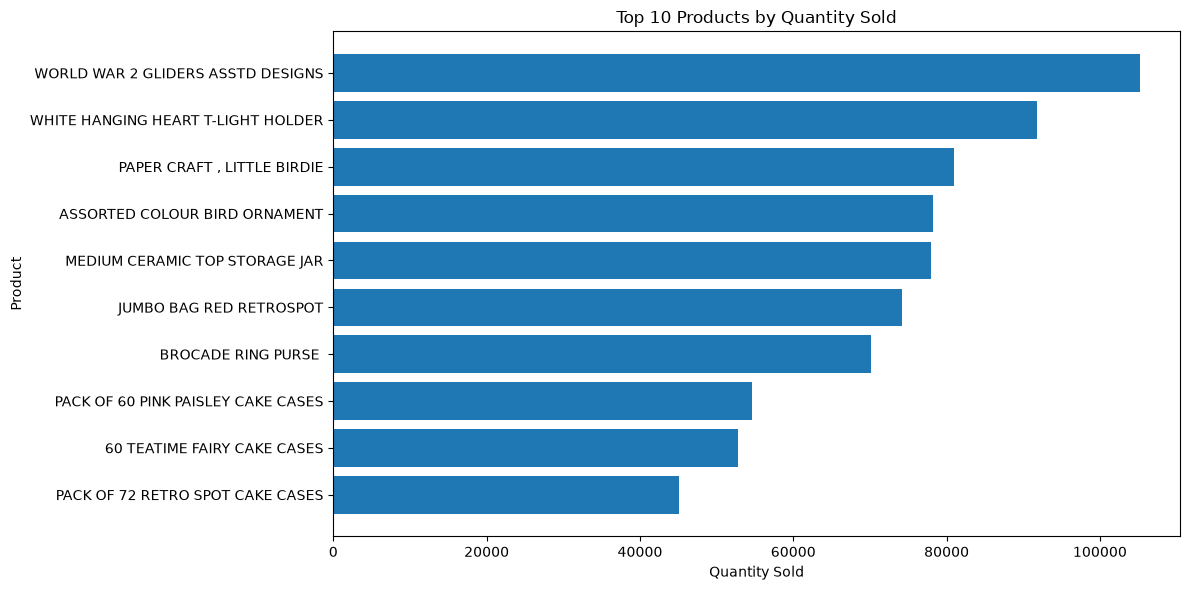

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\top_quantity_products.png


In [69]:
# ============================================================
# Visualization - Top Products by Quantity Sold
# ============================================================

plt.figure(figsize=(12,6))

plt.barh(
    top_products_quantity["Description"],
    top_products_quantity["Quantity"]
)

plt.title("Top 10 Products by Quantity Sold")

plt.xlabel("Quantity Sold")

plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()

import os


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'top_quantity_products.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

Products with the highest sales volume represent the most popular items among customers.

Maintaining sufficient stock of these products is essential to avoid lost sales due to stock shortages.

## 3.3 Lowest Performing Products

### Business Question

**Which products generated the lowest revenue?**

Identifying underperforming products helps businesses evaluate whether these items should be improved, discounted, or discontinued.

In [70]:
# ============================================================
# Lowest Performing Products
# ============================================================

lowest_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
      .reset_index()
)

lowest_products

,Description,Revenue
0,PADS TO MATCH ALL CUSHIONS,0.017
1,PINK HEART CHRISTMAS DECORATION,0.380
2,HAPPY BIRTHDAY GINGER CAT CARD,0.380
3,SET 12 COLOURING PENCILS DOILEY,0.650
4,CAT W SUNGLASSES BLANK CARD,0.760
5,OWLS CHARLOTTE BAG,0.850
6,CAT WITH SUNGLASSES BLANK CARD,0.950
7,SET 36 COLOURING PENCILS DOILEY,1.250
8,FOLKART HEART CHRISTMAS DECORATIONS,1.250
9,WHITE SCANDINAVIAN HEART CHRISTMAS,1.250


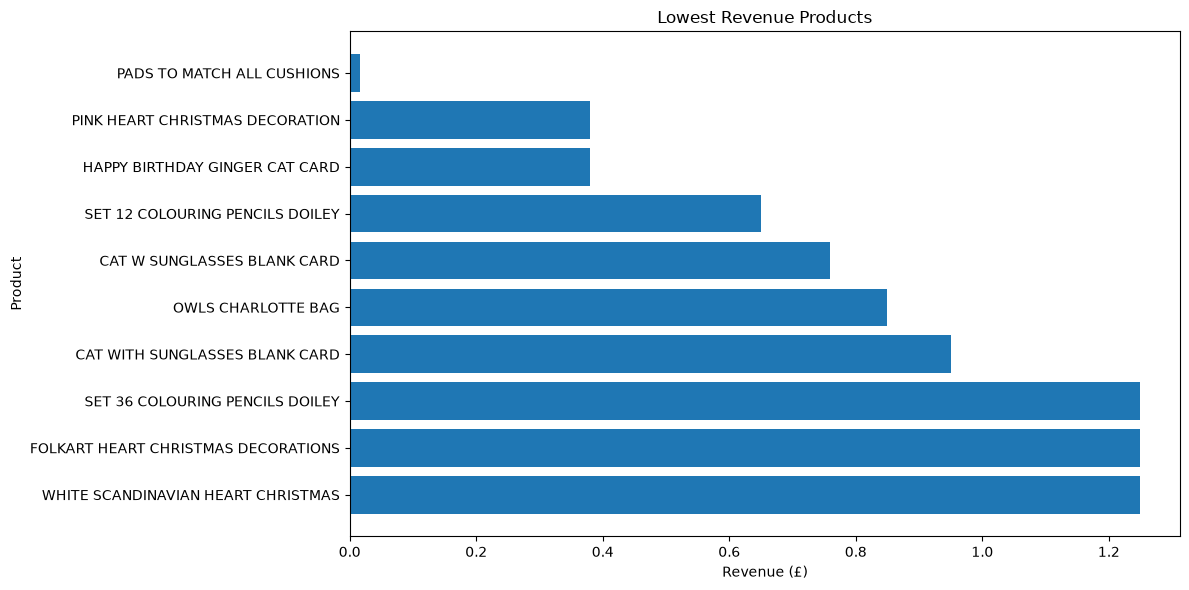

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\lowest_revenue_products.png


In [71]:
# ============================================================
# Visualization - Lowest Performing Products
# ============================================================

plt.figure(figsize=(12,6))

plt.barh(
    lowest_products["Description"],
    lowest_products["Revenue"]
)

plt.title("Lowest Revenue Products")

plt.xlabel("Revenue (£)")

plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()

import os


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'lowest_revenue_products.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

Products generating consistently low revenue may require further investigation.

Possible reasons include:

- Low customer demand
- Poor product visibility
- High competition
- Seasonal relevance

Further analysis can determine whether these products should be retained or removed from the product catalog.

## 3.4 Product Revenue Distribution

### Business Question

**How is revenue distributed across products?**

Revenue distribution helps determine whether business revenue is concentrated among a few products or spread across many products.

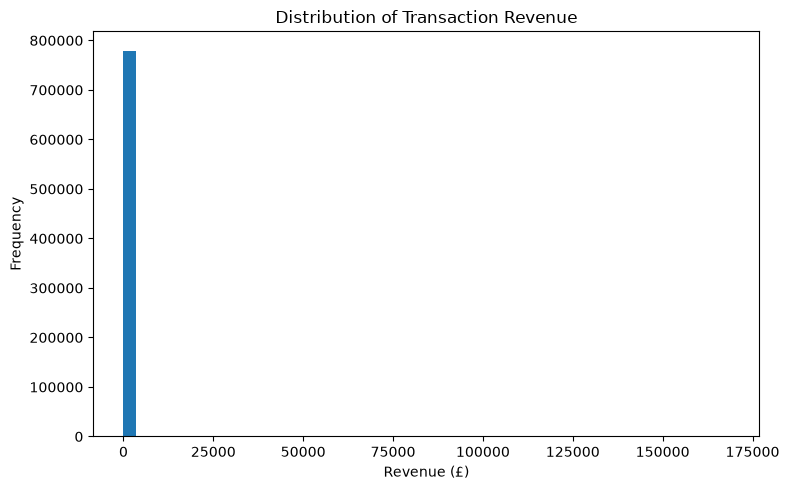

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\revenue_distribution.png


In [72]:
# ============================================================
# Product Revenue Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df["Revenue"], bins=50)

plt.title("Distribution of Transaction Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Frequency")

plt.tight_layout()

import os


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'revenue_distribution.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

The distribution illustrates how transaction revenue is spread across all sales.

If the distribution is highly skewed, it indicates that a small number of transactions generate a large portion of the total revenue.

## Product Analysis Summary

The product analysis revealed:

- The highest revenue-generating products.
- The most frequently purchased products.
- The lowest-performing products.
- The overall distribution of transaction revenue.

These insights help businesses optimize inventory, improve product strategies, and maximize revenue.

# 👥 Customer Analysis

## Objective

Customers are the foundation of every retail business.

This section analyzes customer purchasing behavior to identify high-value customers and understand how revenue is distributed across the customer base.

The following analyses will be performed:

1. Top 10 Customers by Revenue
2. Top 10 Customers by Number of Orders
3. Customer Spending Distribution
4. Average Revenue per Customer

## 4.1 Top 10 Customers by Revenue

### Business Question

**Which customers generated the highest revenue?**

Identifying high-value customers helps businesses:

- Build customer loyalty programs
- Offer personalized promotions
- Improve customer retention
- Increase long-term revenue

In [73]:
# ============================================================
# Top Customers by Revenue
# ============================================================

top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_customers

,Customer ID,Revenue
0,18102,580987.04
1,14646,528602.52
2,14156,313437.62
3,14911,291420.81
4,17450,244784.25
5,13694,195640.69
6,17511,172132.87
7,16446,168472.50
8,16684,147142.77
9,12415,144458.37


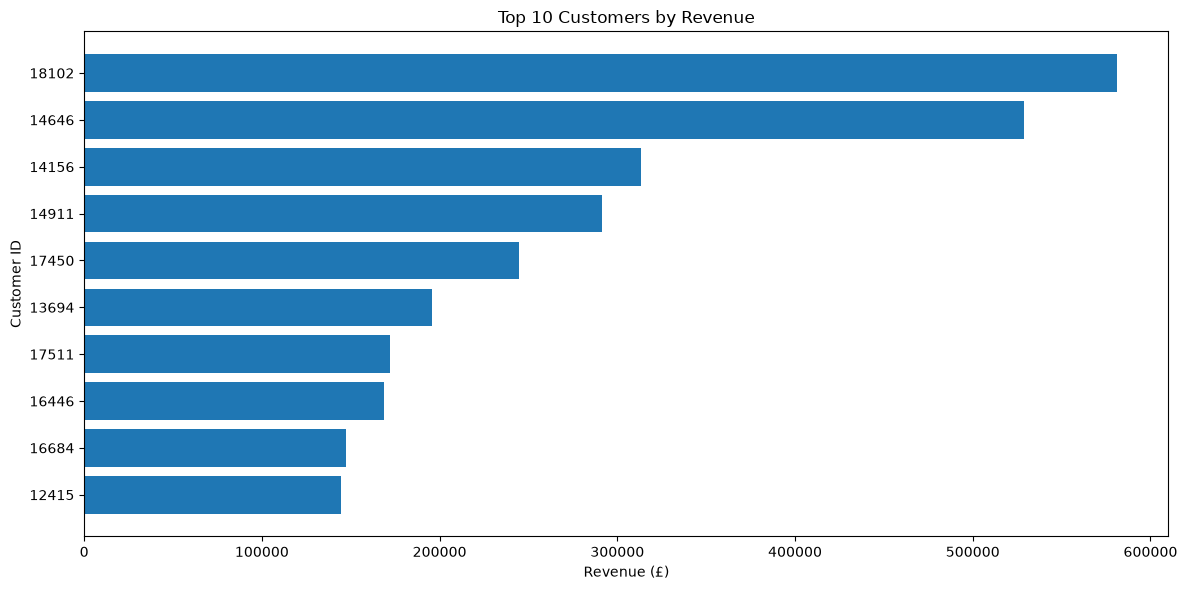

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\Top_customers.png


In [74]:
# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(12,6))

plt.barh(
    top_customers["Customer ID"].astype(str),
    top_customers["Revenue"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()



script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'Top_customers.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

A relatively small number of customers contribute a significant portion of total revenue.

These high-value customers should be prioritized through loyalty programs, personalized offers, and excellent customer service.

## 4.2 Top Customers by Number of Orders

### Business Question

**Which customers place the highest number of orders?**

Some customers may purchase frequently but spend less per order.

Understanding purchase frequency helps identify loyal customers.

In [75]:
# ============================================================
# Top Customers by Orders
# ============================================================

top_orders = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Orders")
)

top_orders

,Customer ID,Orders
0,14911,398
1,12748,336
2,17841,211
3,15311,208
4,13089,203
5,14606,192
6,14156,156
7,17850,155
8,14646,151
9,18102,145


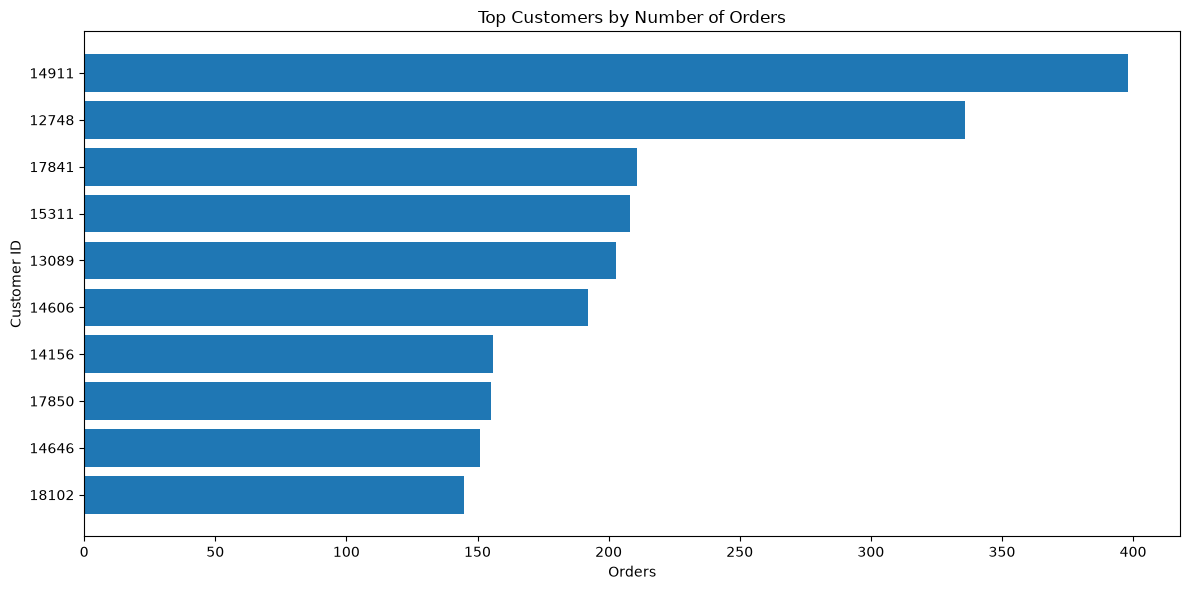

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\Top_customers_orders.png


In [76]:
plt.figure(figsize=(12,6))

plt.barh(
    top_orders["Customer ID"].astype(str),
    top_orders["Orders"]
)

plt.gca().invert_yaxis()

plt.title("Top Customers by Number of Orders")

plt.xlabel("Orders")

plt.ylabel("Customer ID")

plt.tight_layout()




script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'Top_customers_orders.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

Customers who purchase frequently are important for maintaining stable revenue.

These customers may benefit from subscription programs, loyalty rewards, or exclusive offers.

## 4.3 Customer Spending Distribution

### Business Question

**How much do customers spend?**

Understanding customer spending patterns helps identify whether revenue comes from many small customers or a few large customers.

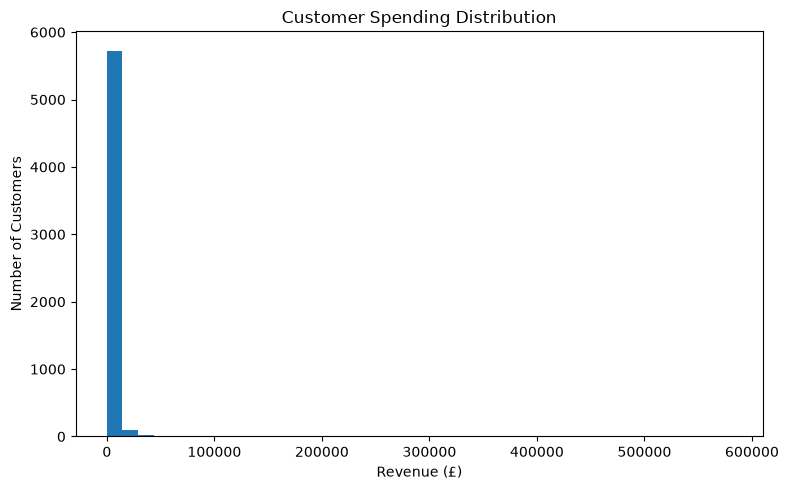

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\custmer_spending _distribution.png


In [77]:
customer_spending = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
)

plt.figure(figsize=(8,5))

plt.hist(customer_spending, bins=40)

plt.title("Customer Spending Distribution")

plt.xlabel("Revenue (£)")

plt.ylabel("Number of Customers")

plt.tight_layout()

import os


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'custmer_spending _distribution.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

## Customer Analysis Summary

Key findings include:

- Highest revenue-generating customers.
- Customers with the greatest purchasing frequency.
- Overall customer spending patterns.

These insights support customer retention strategies and targeted marketing campaigns.

# 🌍 Country Analysis

## Objective

Country-level analysis helps identify geographic markets that contribute the most revenue and customer activity.

This analysis answers questions such as:

- Which countries generate the highest revenue?
- Which countries place the most orders?
- Where are the most customers located?

## 5.1 Revenue by Country

In [78]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

country_revenue

,Country,Revenue
0,United Kingdom,1.438923e+07
1,EIRE,6.165705e+05
2,Netherlands,5.540381e+05
3,Germany,4.250197e+05
4,France,3.487690e+05
5,Australia,1.692835e+05
6,Spain,1.083325e+05
7,Switzerland,1.000619e+05
8,Sweden,9.151582e+04
9,Denmark,6.858069e+04


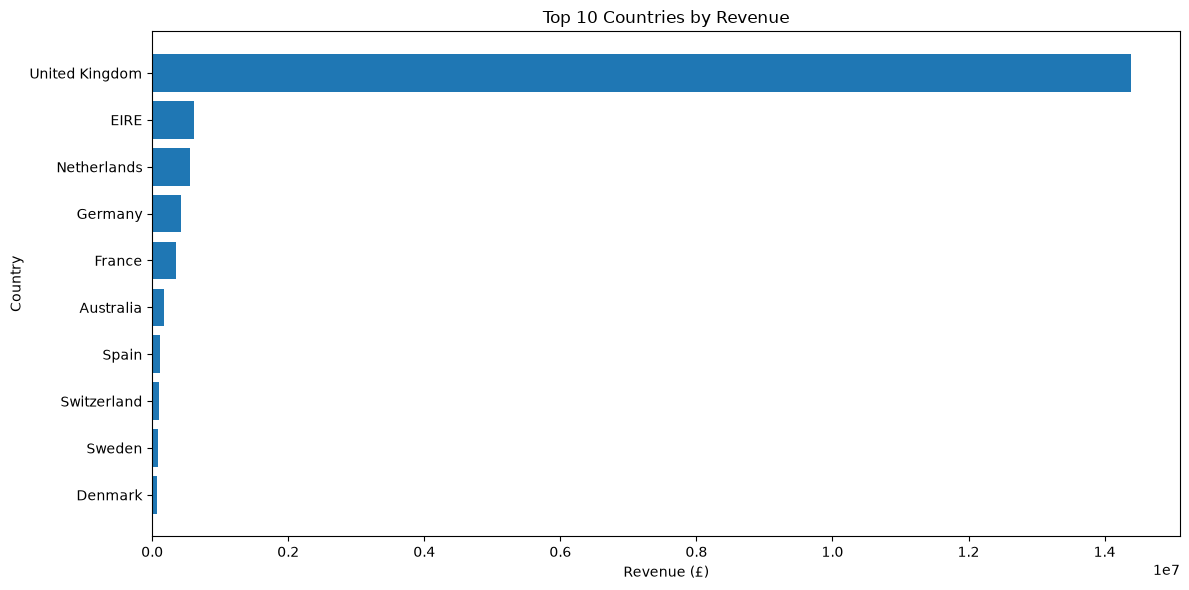

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\Top_countries.png


In [79]:
plt.figure(figsize=(12,6))

plt.barh(
    country_revenue["Country"],
    country_revenue["Revenue"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Country")

plt.tight_layout()




script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)

save_path = os.path.join(target_dir, 'Top_countries.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

### Business Insight

The highest revenue-generating countries represent the company's strongest international markets.

These markets may offer opportunities for additional investment, marketing, and expansion.

## 5.2 Orders by Country

In [80]:
country_orders = (
    df.groupby("Country")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Orders")
)

country_orders

,Country,Orders
0,United Kingdom,33541
1,Germany,789
2,France,614
3,EIRE,567
4,Netherlands,228
5,Spain,154
6,Belgium,149
7,Sweden,104
8,Australia,95
9,Portugal,93


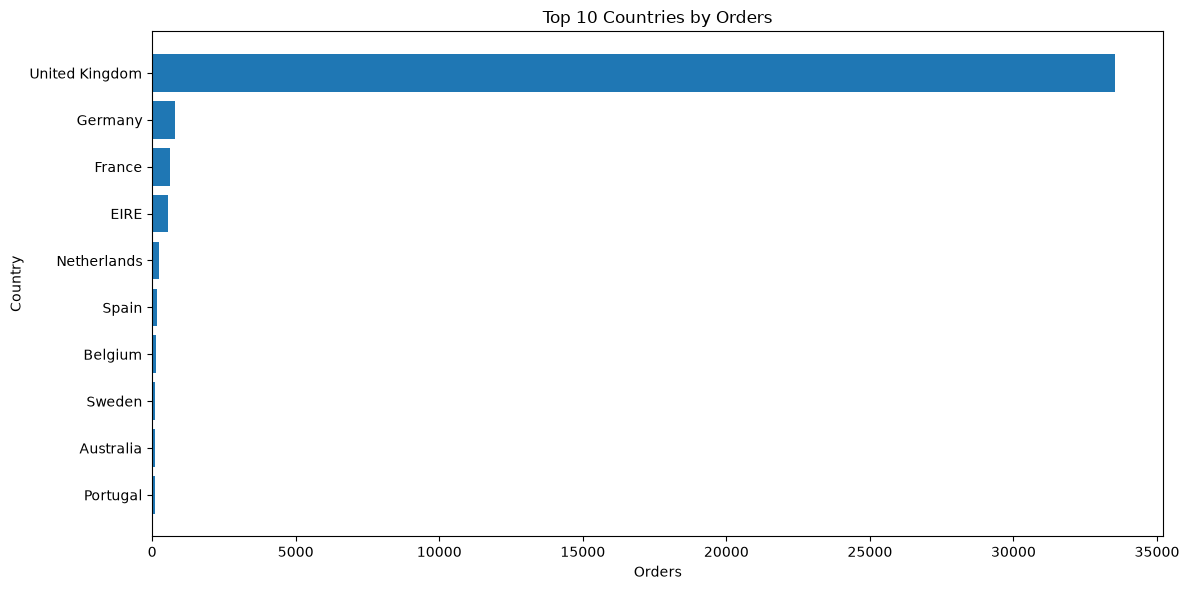

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\Countries_orders.png


In [81]:
plt.figure(figsize=(12,6))

plt.barh(
    country_orders["Country"],
    country_orders["Orders"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Countries by Orders")

plt.xlabel("Orders")

plt.ylabel("Country")

plt.tight_layout()




script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'Countries_orders.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

# Country Analysis Summary

The country analysis identified the company's strongest geographic markets based on revenue and customer activity.

These insights can support expansion strategies and regional marketing campaigns.

# ⏰ Time Analysis

## Objective

Understanding when customers shop helps businesses optimize staffing, marketing campaigns, and promotional timing.

This section analyzes customer purchasing behavior by weekday and hour.

## 6.1 Revenue by Weekday

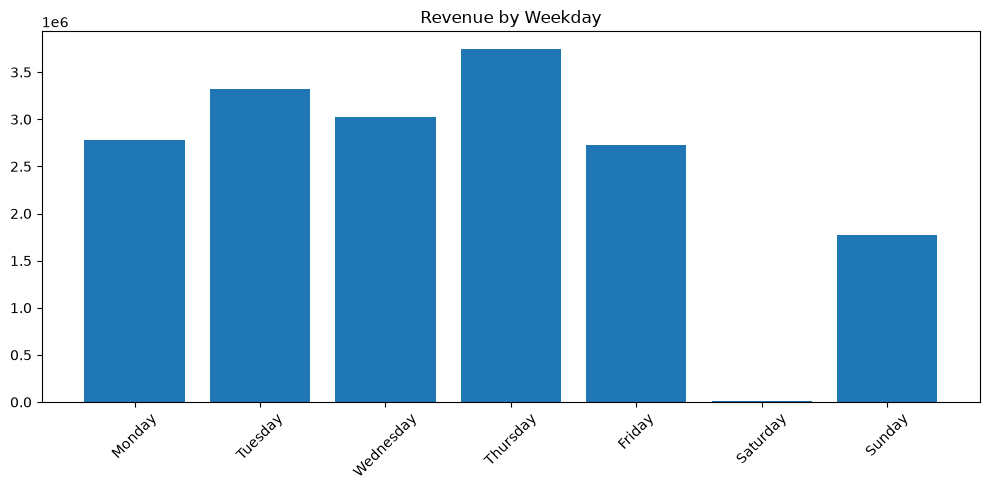

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\weekdays_sales.png


In [82]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue = (
    df.groupby("Weekday")["Revenue"]
      .sum()
      .reindex(weekday_order)
)

plt.figure(figsize=(10,5))

plt.bar(
    weekday_revenue.index,
    weekday_revenue.values
)

plt.title("Revenue by Weekday")

plt.xticks(rotation=45)

plt.tight_layout()


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()


target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'weekdays_sales.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

## 6.2 Revenue by Hour

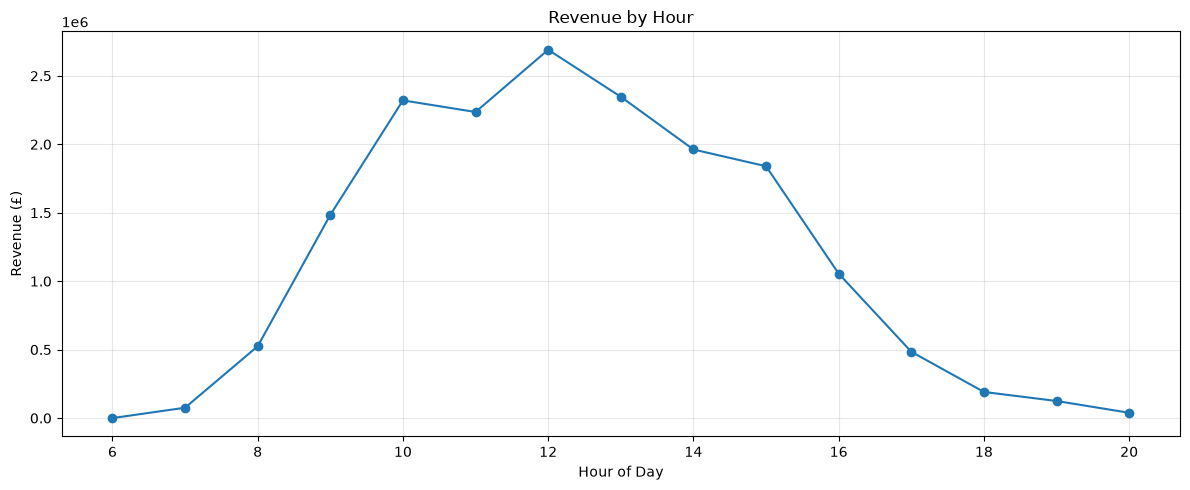

Success! Your image was saved directly to: c:\Users\Jack\Desktop\online_retail_analysis\images\hourly_sales.png


In [83]:
hourly_sales = (
    df.groupby("Hour")["Revenue"]
      .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    hourly_sales.index,
    hourly_sales.values,
    marker="o"
)

plt.title("Revenue by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Revenue (£)")

plt.grid(alpha=0.3)

plt.tight_layout()


script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()

target_dir = os.path.join(script_dir, 'images')
os.makedirs(target_dir, exist_ok=True)


save_path = os.path.join(target_dir, 'hourly_sales.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Your image was saved directly to: {save_path}")


plt.show()

## Time Analysis Summary

Time-based analysis helps identify:

- Peak shopping days
- Peak shopping hours
- Customer purchasing behavior

These insights can improve staffing schedules and marketing campaign timing.

# 📌 Final Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Maintain sufficient inventory for the highest revenue-generating products.
2. Develop loyalty programs for high-value customers.
3. Focus marketing efforts on the top-performing countries.
4. Schedule promotional campaigns during peak shopping periods.
5. Investigate underperforming products to determine whether improvements or discontinuation are appropriate.
6. Monitor month-over-month revenue trends to identify growth opportunities and respond quickly to declining sales.

# 🎯 Project Conclusion

This project analyzed the Online Retail II dataset using Python to transform raw transactional data into actionable business insights.

The workflow included:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Business KPI Reporting
- Sales Analysis
- Product Analysis
- Customer Analysis
- Country Analysis
- Time Analysis

The cleaned dataset is ready for further analysis in SQL and visualization in Power BI.

This project demonstrates practical data analysis skills, including data preprocessing, exploratory analysis, visualization, and business storytelling using Python.

In [84]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day', 'Weekday', 'Hour']
